<a href="https://colab.research.google.com/github/Apoorv070/Project-Aegis/blob/main/Project_Aegisipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚀 Project Aegis: Advanced Enterprise RAG System
## System Overview

This notebook implements an advanced RAG system with:

### Part 1: Ingestion Engine
- ✅ Markdown-aware semantic chunking (preserves headers & tables)
- ✅ 10-15% token overlap between chunks
- ✅ LLM-powered metadata extraction
- ✅ Dense embeddings (OpenAI text-embedding-3-large)
- ✅ Pinecone vector database with metadata filtering

### Part 2: Advanced Retrieval
- ✅ Multi-query expansion (3-4 variations)
- ✅ HyDE (Hypothetical Document Embeddings)
- ✅ Pre-filtering by policy category
- ✅ Post-filtering by effective date
- ✅ Cross-encoder reranking (Cohere ReRank)

### Part 3: Generation
- ✅ Context-aware answer generation
- ✅ Source citations
- ✅ Confidence scoring

## 📦 Step 1: Install Dependencies

In [ ]:
%%capture
#!pip install pinecone-client openai cohere tiktoken tqdm

In [17]:
%%capture
# Uninstall old package first, then install correct ones
#!pip uninstall -y pinecone-client
!pip install -U pinecone openai cohere tiktoken tqdm

## 📚 Step 2: Import Libraries

In [18]:
import os
import re
import json
import time
from typing import List, Dict, Optional
from datetime import datetime
from collections import defaultdict

# Google Colab
from google.colab import drive

# AI Services
from pinecone import Pinecone, ServerlessSpec
from openai import OpenAI
import cohere

# Utils
import tiktoken
from tqdm.auto import tqdm

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 💾 Step 3: Mount Google Drive

In [19]:
# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
# Set your data directory path - points to the Data folder with subfolders
DATA_DIR = "/content/drive/MyDrive/Project-Rag/Data"

print(f"📂 Data directory: {DATA_DIR}")
print(f"\n📁 Subfolders and files found:")
if os.path.exists(DATA_DIR):
    for item in os.listdir(DATA_DIR):
        item_path = os.path.join(DATA_DIR, item)
        if os.path.isdir(item_path):
            # Show all files in each subfolder with their extensions
            files = os.listdir(item_path)
            if files:
                print(f"\n   📁 {item}/")
                for f in files[:5]:  # Show first 5 files
                    print(f"      - {f}")
                if len(files) > 5:
                    print(f"      ... and {len(files) - 5} more files")
            else:
                print(f"\n   📁 {item}/ (empty)")
else:
    print(f"⚠️ Directory not found! Please update DATA_DIR path.")

📂 Data directory: /content/drive/MyDrive/Project-Rag/Data

📁 Subfolders and files found:

   📁 Work Policies/
      - travel
      - leave_and_absence.txt
      - code of conduct.txt
      - performance and compensation.txt

   📁 .ipynb_checkpoints/ (empty)

   📁 travel/
      - International Travel.txt
      - Travel Policy.txt
      - Fuel and Mileage Policy.txt

   📁 training/
      - learning and tuition.txt

   📁 security/
      - it security and data privacy.txt


## 🔑 Step 4: Configure API Keys

In [21]:
# Fetch API keys from Colab secrets
from google.colab import userdata

OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')
PINECONE_API_KEY = userdata.get('PINECONE_API_KEY')
COHERE_API_KEY = userdata.get('COHERE_API_KEY')

# Initialize clients
openai_client = OpenAI(api_key=OPENAI_API_KEY)
pc = Pinecone(api_key=PINECONE_API_KEY)
cohere_client = cohere.Client(COHERE_API_KEY)

# Configuration
EMBEDDING_MODEL = "text-embedding-3-large"
EMBEDDING_DIMENSION = 3072
INDEX_NAME = "project-aegis-rag"
LLM_MODEL = "gpt-4o-mini"

print("✅ API clients initialized successfully!")
print(f"   - Embedding Model: {EMBEDDING_MODEL}")
print(f"   - LLM Model: {LLM_MODEL}")
print(f"   - Index Name: {INDEX_NAME}")

✅ API clients initialized successfully!
   - Embedding Model: text-embedding-3-large
   - LLM Model: gpt-4o-mini
   - Index Name: project-aegis-rag


## 📤 Step 5: Upload Helper Module

Upload the `aegis_rag_helpers.py` file to Colab, or run the cell below to download it from your Drive.

In [23]:
# Add the directory (not the file) to Python path
import sys
sys.path.append('/content/drive/MyDrive/Project-Rag')

# Import helper classes (no .py extension in import)
from aegis_rag_helpers import (
    MarkdownSemanticChunker,
    MetadataExtractor,
    EmbeddingPipeline,
    QueryTransformer,
    MetadataFilter,
    Reranker,
    AdvancedRetriever,
    RAGGenerator,
    ProjectAegisRAG
)

print("✅ Helper classes imported successfully!")

✅ Helper classes imported successfully!


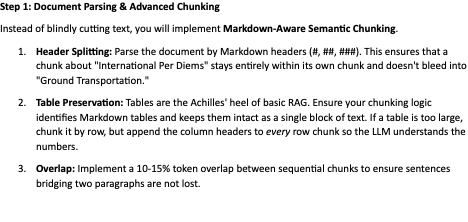

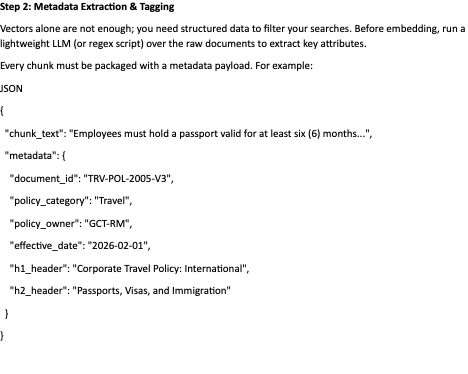

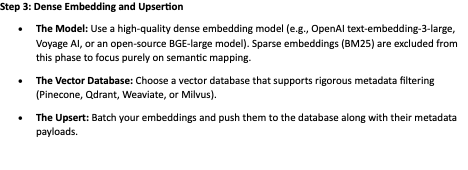

---
# 🔧 PART 1: INGESTION ENGINE

Process documents and load into Pinecone vector database

In [24]:
def ingest_documents(data_dir: str, openai_client, pinecone_client, index_name: str):
    """
    Complete ingestion pipeline:
    1. Load text files from Drive (.txt, .md, .markdown)
    2. Chunk with semantic awareness
    3. Extract metadata using LLM
    4. Generate embeddings
    5. Upsert to Pinecone
    """

    print("\n" + "="*60)
    print("🚀 STARTING INGESTION PIPELINE")
    print("="*60)

    # Initialize components
    chunker = MarkdownSemanticChunker(max_tokens=500, overlap_percentage=0.15)
    metadata_extractor = MetadataExtractor(openai_client)
    embedding_pipeline = EmbeddingPipeline(
        openai_client,
        pinecone_client,
        index_name,
        EMBEDDING_MODEL,
        EMBEDDING_DIMENSION
    )

    # Create/connect to index
    embedding_pipeline.create_index()

    # Find all text and markdown files
    text_files = []
    for root, dirs, files in os.walk(data_dir):
        for file in files:
            if file.endswith(('.md', '.markdown', '.txt')):
                text_files.append(os.path.join(root, file))

    print(f"\n📁 Found {len(text_files)} text/markdown files")

    if len(text_files) == 0:
        print("⚠️ No text files found! Check your DATA_DIR path.")
        return []

    all_enriched_chunks = []

    # Process each document
    for filepath in tqdm(text_files, desc="Processing documents"):
        filename = os.path.basename(filepath)
        print(f"\n📄 Processing: {filename}")

        try:
            # Read file
            with open(filepath, 'r', encoding='utf-8') as f:
                text = f.read()

            if not text.strip():
                print(f"   ⚠️ Empty file, skipping")
                continue

            # Extract document metadata
            doc_metadata = metadata_extractor.extract_document_metadata(filename, text)
            print(f"   📋 Category: {doc_metadata['policy_category']}")
            print(f"   📋 Document ID: {doc_metadata['document_id']}")

            # Chunk document
            chunks = chunker.chunk_document(text)
            print(f"   ✂️ Created {len(chunks)} chunks")

            # Enrich with metadata
            for chunk in chunks:
                enriched = metadata_extractor.enrich_chunk_metadata(chunk, doc_metadata)
                all_enriched_chunks.append(enriched)

        except Exception as e:
            print(f"   ❌ Error processing {filename}: {e}")
            continue

    print(f"\n📊 Total chunks across all documents: {len(all_enriched_chunks)}")

    if len(all_enriched_chunks) == 0:
        print("⚠️ No chunks created! Check your documents.")
        return []

    # Upsert to Pinecone
    print("\n🔄 Uploading to Pinecone...")
    embedding_pipeline.upsert_chunks(all_enriched_chunks)

    print("\n" + "="*60)
    print("✅ INGESTION COMPLETE!")
    print("="*60)

    return all_enriched_chunks

print("✅ Ingestion function defined")

✅ Ingestion function defined


In [25]:
# Run the complete ingestion pipeline
enriched_chunks = ingest_documents(
    data_dir=DATA_DIR,
    openai_client=openai_client,
    pinecone_client=pc,
    index_name=INDEX_NAME
)

print(f"\n✅ Ingestion complete! {len(enriched_chunks)} chunks indexed.")


🚀 STARTING INGESTION PIPELINE
Creating index: project-aegis-rag
✅ Connected to index: project-aegis-rag

📁 Found 8 text/markdown files


Processing documents:   0%|          | 0/8 [00:00<?, ?it/s]


📄 Processing: leave_and_absence.txt
   📋 Category: HR
   📋 Document ID: HR-POL-4001-V6
   ✂️ Created 30 chunks

📄 Processing: code of conduct.txt
   📋 Category: HR
   📋 Document ID: HR-POL-5050-V4
   ✂️ Created 26 chunks

📄 Processing: performance and compensation.txt
   📋 Category: HR
   📋 Document ID: HR-POL-6002-V5
   ✂️ Created 24 chunks

📄 Processing: International Travel.txt
   📋 Category: Travel
   📋 Document ID: TRV-POL-2005
   ✂️ Created 35 chunks

📄 Processing: Travel Policy.txt
   📋 Category: Travel
   📋 Document ID: TRV-POL-1001-V4
   ✂️ Created 37 chunks

📄 Processing: Fuel and Mileage Policy.txt
   📋 Category: Travel
   📋 Document ID: TRV-POL-3012-V2
   ✂️ Created 27 chunks

📄 Processing: learning and tuition.txt
   📋 Category: HR
   📋 Document ID: LND-POL-7010-V3
   ✂️ Created 20 chunks

📄 Processing: it security and data privacy.txt
   📋 Category: IT
   📋 Document ID: SEC-POL-8005-V7
   ✂️ Created 17 chunks

📊 Total chunks across all documents: 216

🔄 Uploading to Pine

Embedding:   0%|          | 0/3 [00:00<?, ?it/s]

Upserting 216 vectors to Pinecone...


Upserting:   0%|          | 0/3 [00:00<?, ?it/s]

✅ Upserted 216 vectors to Pinecone

✅ INGESTION COMPLETE!

✅ Ingestion complete! 216 chunks indexed.


In [26]:
# Check Pinecone index stats
index = pc.Index(INDEX_NAME)
stats = index.describe_index_stats()

print("\n📊 Pinecone Index Statistics:")
print(f"   Total vectors: {stats['total_vector_count']}")
print(f"   Dimension: {stats['dimension']}")
print(f"\n✅ Index is ready for queries!")


📊 Pinecone Index Statistics:
   Total vectors: 216
   Dimension: 3072

✅ Index is ready for queries!


---
# 🔍 PART 2: ADVANCED RETRIEVAL & GENERATION

Initialize the complete RAG system

## Initialize RAG System

In [27]:
# Get Pinecone index
index = pc.Index(INDEX_NAME)

# Create complete RAG system
rag_system = ProjectAegisRAG(
    openai_client=openai_client,
    cohere_client=cohere_client,
    pinecone_index=index,
    embedding_model=EMBEDDING_MODEL,
    llm_model=LLM_MODEL
)

print("\n" + "="*60)
print("✅ PROJECT AEGIS RAG SYSTEM READY!")
print("="*60)
print("\nFeatures enabled:")
print("   ✅ Multi-query expansion")
print("   ✅ HyDE (Hypothetical Document Embeddings)")
print("   ✅ Metadata pre-filtering")
print("   ✅ Date-based post-filtering")
print("   ✅ Cross-encoder reranking (Cohere)")
print("   ✅ Source citations")
print("\nReady to answer questions!")


✅ PROJECT AEGIS RAG SYSTEM READY!

Features enabled:
   ✅ Multi-query expansion
   ✅ HyDE (Hypothetical Document Embeddings)
   ✅ Metadata pre-filtering
   ✅ Date-based post-filtering
   ✅ Cross-encoder reranking (Cohere)
   ✅ Source citations

Ready to answer questions!


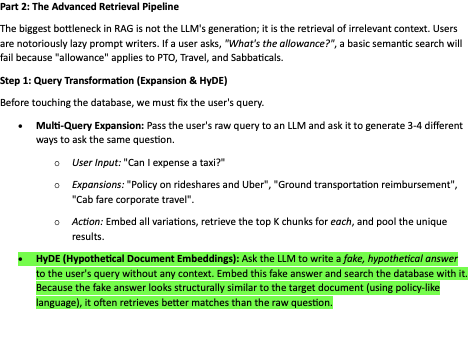

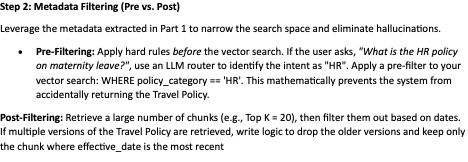

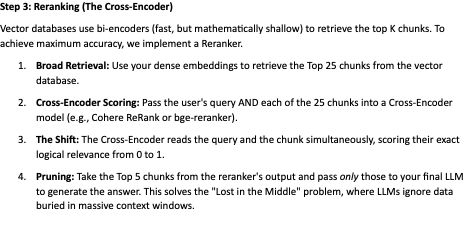

# 🧪 TESTING & EXAMPLES

## Test Query 1: Travel Policy

In [28]:
result = rag_system.query(
    "What is the per diem allowance for international travel?",
    top_k=5,
    use_hyde=True
)

print("\n" + "="*60)
print("💡 ANSWER:")
print("="*60)
print(result['answer'])
print("\n" + "="*60)
print("📚 SOURCES:")
print("="*60)
for i, source in enumerate(result['sources'], 1):
    print(f"{i}. {source['document_title']}")
    print(f"   Section: {source['section']}")
    print(f"   Relevance Score: {source['rerank_score']:.3f}\n")
print(f"🎯 Confidence: {result['confidence'].upper()}")


🔍 Query: What is the per diem allowance for international travel?
   Expanded to 4 variations
   Generated HyDE answer
   Pre-filter: {'policy_category': {'$eq': 'Travel'}}
   Retrieved 38 unique chunks
   After date filtering: 9 chunks
   Final top-5 after reranking

💡 ANSWER:
The per diem allowance for international travel is not a flat rate; it is dynamically assigned based on the destination city, utilizing the World Health Organization (WHO) or US State Department international per diem tables. Receipts are not required for meals purchased under the international per diem threshold, which covers all gratuities, currency exchange fees, and minor local transit expenses [Source 1]. 

For standard domestic travel, the per diem is set at $85.00 USD per full day, with travel days (first and last day) prorated to 75% of the standard per diem, amounting to $63.75 USD [Source 2]. However, specific figures for international per diem amounts based on destination cities are not provided in t

## Test Query 2: HR Policy

In [29]:
result = rag_system.query(
    "How many days of parental leave am I entitled to?",
    top_k=5
)

print("\n" + "="*60)
print("💡 ANSWER:")
print("="*60)
print(result['answer'])
print("\n" + "="*60)
print("📚 SOURCES:")
print("="*60)
for i, source in enumerate(result['sources'], 1):
    print(f"{i}. {source['document_title']} - {source['section']}")
print(f"\n🎯 Confidence: {result['confidence'].upper()}")


🔍 Query: How many days of parental leave am I entitled to?
   Expanded to 4 variations
   Generated HyDE answer
   Pre-filter: {'policy_category': {'$eq': 'HR'}}
   Retrieved 30 unique chunks
   After date filtering: 7 chunks
   Final top-5 after reranking

💡 ANSWER:
You are entitled to up to sixteen (16) weeks of 100% paid parental leave if you are designated as the Primary Caregiver, which is the parent taking primary responsibility for the child's care during standard business hours. This leave must be taken within twelve (12) months of the child's birth or placement and can be taken intermittently in blocks of no less than one (1) week at a time [Source 3][Source 2].

📚 SOURCES:
1. Human Resources Policy: Global Leave, Paid Time Off, and Absences - Human Resources Policy: Global Leave, Paid Time Off, and Absences > 6. Comprehensive Parental and Family Leave
2. Human Resources Policy: Global Leave, Paid Time Off, and Absences - Human Resources Policy: Global Leave, Paid Time Off, a

## Test Query 3: Vague Query (Tests Query Expansion)

In [30]:
result = rag_system.query(
    "Can I expense a taxi?",
    top_k=5
)

print("\n" + "="*60)
print("💡 ANSWER:")
print("="*60)
print(result['answer'])
print("\n" + "="*60)
print("📚 SOURCES:")
print("="*60)
for i, source in enumerate(result['sources'], 1):
    print(f"{i}. {source['document_title']} - {source['section']}")
print(f"\n🎯 Confidence: {result['confidence'].upper()}")


🔍 Query: Can I expense a taxi?
   Expanded to 4 variations
   Generated HyDE answer
   Pre-filter: {'policy_category': {'$eq': 'Travel'}}
   Retrieved 42 unique chunks
   After date filtering: 9 chunks
   Final top-5 after reranking

💡 ANSWER:
Yes, you can expense a taxi for transportation between the airport, hotel, and client locations. The use of licensed taxis is approved under the corporate travel policy. However, it is important to select the standard tier of service, as premium tiers are prohibited unless accompanied by a client [Source 2].

📚 SOURCES:
1. Corporate Travel Policy: Standard and Client-Facing Operations - Corporate Travel Policy: Standard and Client-Facing Operations > 6. Ground Transportation and Vehicle Policies
2. Corporate Travel Policy: Standard and Client-Facing Operations - Corporate Travel Policy: Standard and Client-Facing Operations > 6. Ground Transportation and Vehicle Policies
3. Corporate Travel Policy: Standard and Client-Facing Operations - Corpora

## Test Query 4: Numerical/Table Query

In [31]:
result = rag_system.query(
    "What are the expense limits for different employee levels?",
    top_k=5
)

print("\n" + "="*60)
print("💡 ANSWER:")
print("="*60)
print(result['answer'])
print("\n" + "="*60)
print("📚 SOURCES:")
print("="*60)
for i, source in enumerate(result['sources'], 1):
    print(f"{i}. {source['document_title']} - {source['section']}")
print(f"\n🎯 Confidence: {result['confidence'].upper()}")


🔍 Query: What are the expense limits for different employee levels?
   Expanded to 4 variations
   Generated HyDE answer
   Pre-filter: {'policy_category': {'$eq': 'HR'}}
   Retrieved 48 unique chunks
   After date filtering: 12 chunks
   Final top-5 after reranking

💡 ANSWER:
The expense limits for different employee levels regarding the Professional Development Stipend are as follows:

| Job Level                     | Annual L&D Stipend Limit (USD) | Approval Required         |
|-------------------------------|---------------------------------|---------------------------|
| Individual Contributors (L1 - L4) | $1,500                          | Direct Manager            |
| Management (M1 - M2)         | $3,000                          | Department Director       |
| Directors and Above (D1+)     | $5,000                          | Department VP             |

These stipend amounts are refreshed annually on January 1st and do not roll over into the following calendar year [Source 1].

## Test Individual Components

In [32]:
# Test Query Expansion
from aegis_rag_helpers import QueryTransformer

qt = QueryTransformer(openai_client)
query = "What's the allowance?"
expanded = qt.expand_query(query, num_variations=3)

print("\n🔍 QUERY EXPANSION TEST")
print("="*60)
print(f"Original: {query}")
print("\nExpanded variations:")
for i, var in enumerate(expanded, 1):
    print(f"{i}. {var}")


🔍 QUERY EXPANSION TEST
Original: What's the allowance?

Expanded variations:
1. What's the allowance?
2. What is the permissible limit for allowances?
3. Can you clarify the allowance guidelines?
4. What is the allocated amount for allowances?


In [33]:
# Test HyDE
query = "Can I expense a taxi?"
hyde_answer = qt.generate_hyde(query)

print("\n🎭 HyDE TEST")
print("="*60)
print(f"Query: {query}")
print(f"\nHypothetical Answer:\n{hyde_answer}")


🎭 HyDE TEST
Query: Can I expense a taxi?

Hypothetical Answer:
**Expense Reimbursement Policy Excerpt: Transportation Expenses**

Employees may expense taxi fares incurred while conducting company business, provided that the total fare does not exceed $50 per trip. To ensure reimbursement, employees must submit a detailed receipt along with a completed Expense Reimbursement Form within 30 days of the travel date. All expenses are subject to managerial approval and must align with the company's travel guidelines.


In [34]:
# Test Category Detection
from aegis_rag_helpers import MetadataFilter

mf = MetadataFilter(openai_client)

test_queries = [
    "How much vacation do I get?",
    "Can I expense a flight?",
    "How do I reset my password?",
    "What's the reimbursement policy?"
]

print("\n🏷️ CATEGORY DETECTION TEST")
print("="*60)
for query in test_queries:
    category = mf.detect_category(query)
    print(f"Query: {query}")
    print(f"Category: {category}\n")


🏷️ CATEGORY DETECTION TEST
Query: How much vacation do I get?
Category: HR

Query: Can I expense a flight?
Category: Travel

Query: How do I reset my password?
Category: IT

Query: What's the reimbursement policy?
Category: Finance



## Performance Metrics

In [35]:
import time

# Measure query latency
test_query = "What is the travel policy?"

start_time = time.time()
result = rag_system.query(test_query, top_k=5)
end_time = time.time()

latency = end_time - start_time

print("\n⚡ PERFORMANCE METRICS")
print("="*60)
print(f"Query: {test_query}")
print(f"Total Latency: {latency:.2f} seconds")
print(f"Sources Retrieved: {len(result['sources'])}")
print(f"Confidence: {result['confidence']}")
print(f"\nBreakdown (approximate):")
print(f"   - Query expansion: ~1-2s")
print(f"   - Vector search: ~0.5-1s")
print(f"   - Reranking: ~1-2s")
print(f"   - Generation: ~2-3s")


🔍 Query: What is the travel policy?
   Expanded to 4 variations
   Generated HyDE answer
   Pre-filter: {'policy_category': {'$eq': 'Travel'}}
   Retrieved 39 unique chunks
   After date filtering: 9 chunks
   Final top-5 after reranking

⚡ PERFORMANCE METRICS
Query: What is the travel policy?
Total Latency: 14.87 seconds
Sources Retrieved: 5
Confidence: high

Breakdown (approximate):
   - Query expansion: ~1-2s
   - Vector search: ~0.5-1s
   - Reranking: ~1-2s
   - Generation: ~2-3s


## Batch Testing

In [36]:
# Test multiple queries
test_queries = [
    "What is the per diem for London?",
    "How many sick days do I have?",
    "Can I work remotely?",
    "What's the expense approval process?",
    "Do I need a visa for travel?"
]

print("\n🔄 BATCH TESTING")
print("="*60)

results = []
for i, query in enumerate(test_queries, 1):
    print(f"\n[{i}/{len(test_queries)}] Testing: {query}")
    result = rag_system.query(query, top_k=3)
    results.append({
        "query": query,
        "confidence": result['confidence'],
        "num_sources": len(result['sources'])
    })
    print(f"   Confidence: {result['confidence']} | Sources: {len(result['sources'])}")

print("\n" + "="*60)
print("✅ BATCH TEST COMPLETE")
print("="*60)
high_conf = sum(1 for r in results if r['confidence'] == 'high')
print(f"High confidence answers: {high_conf}/{len(results)}")


🔄 BATCH TESTING

[1/5] Testing: What is the per diem for London?

🔍 Query: What is the per diem for London?
   Expanded to 4 variations
   Generated HyDE answer
   Pre-filter: {'policy_category': {'$eq': 'Travel'}}
   Retrieved 42 unique chunks
   After date filtering: 9 chunks
   Final top-3 after reranking
   Confidence: high | Sources: 3

[2/5] Testing: How many sick days do I have?

🔍 Query: How many sick days do I have?
   Expanded to 4 variations
   Generated HyDE answer
   Pre-filter: {'policy_category': {'$eq': 'HR'}}
   Retrieved 30 unique chunks
   After date filtering: 4 chunks
   Final top-3 after reranking
   Confidence: high | Sources: 3

[3/5] Testing: Can I work remotely?

🔍 Query: Can I work remotely?
   Expanded to 4 variations
   Generated HyDE answer
   Pre-filter: {'policy_category': {'$eq': 'HR'}}
   Retrieved 47 unique chunks
   After date filtering: 12 chunks
   Final top-3 after reranking
   Confidence: high | Sources: 3

[4/5] Testing: What's the expense appr

---
# 📋 SUMMARY

## What We Built

✅ **Advanced RAG System** with:
- Markdown-aware chunking (preserves tables & headers)
- LLM-powered metadata extraction
- Multi-query expansion (3-4 variations)
- HyDE (Hypothetical Document Embeddings)
- Metadata pre-filtering by category
- Date-based post-filtering
- Cross-encoder reranking (Cohere)
- Source citations & confidence scoring

## Key Features

1. **Context Preservation**: Tables and headers stay intact
2. **Smart Retrieval**: Query expansion finds relevant docs even with vague questions
3. **Accuracy**: Reranking ensures top results are truly relevant
4. **Transparency**: Every answer includes source citations

## Next Steps

- Add more documents to your Drive folder
- Re-run ingestion to update the index
- Experiment with different queries
- Adjust `top_k` and `use_hyde` parameters
- Monitor performance and accuracy

